In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("data/mental_health.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (16000, 2)


,statement,status
0,feeling so restless lately,Anxiety
1,presentation work is making me feel unable to ...,Stress
2,i am feeling pressured due to daily tasks befo...,Stress
3,sonia natasha mirzayanti,Normal
4,i keep feeling worried because of new situatio...,Anxiety


In [3]:
df.isnull().sum()

statement    0
status       0
dtype: int64

In [4]:
df = df.dropna()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   statement  16000 non-null  object
 1   status     16000 non-null  object
dtypes: object(2)
memory usage: 250.1+ KB


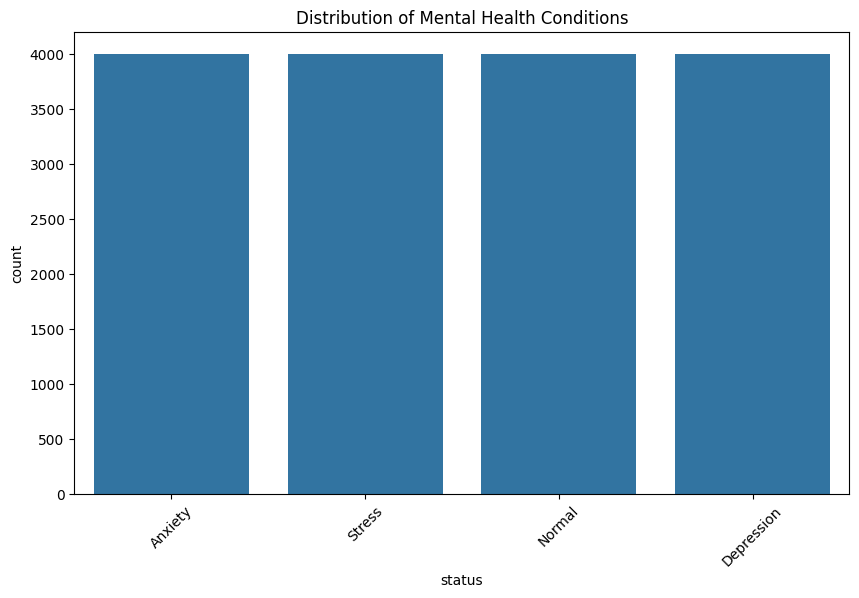

In [6]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="status",
    order=df["status"].value_counts().index
)

plt.title("Distribution of Mental Health Conditions")
plt.xticks(rotation=45)
plt.show()

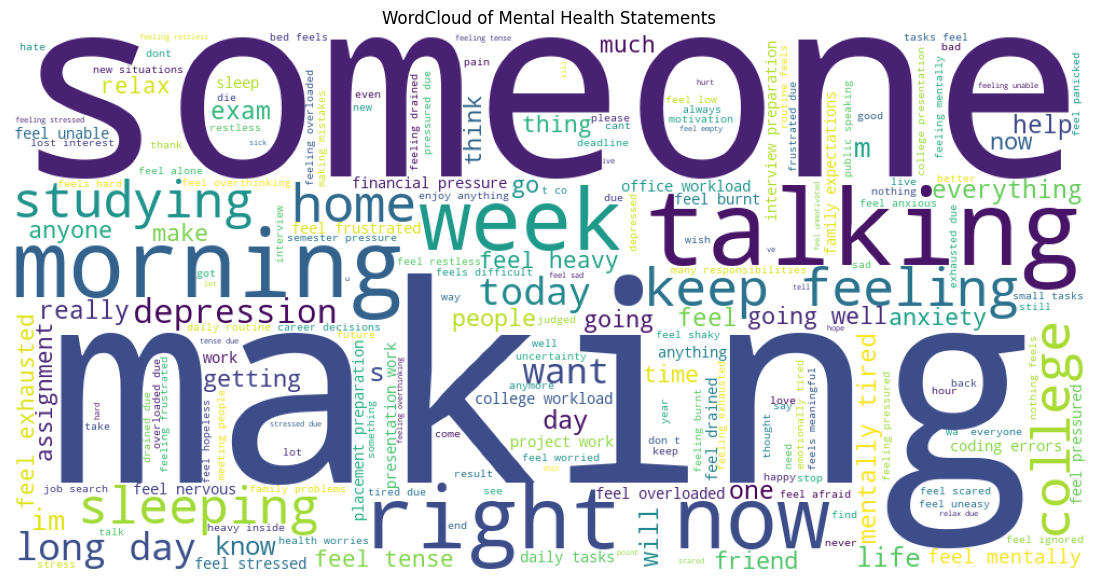

In [7]:
text = " ".join(df["statement"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("WordCloud of Mental Health Statements")

plt.show()

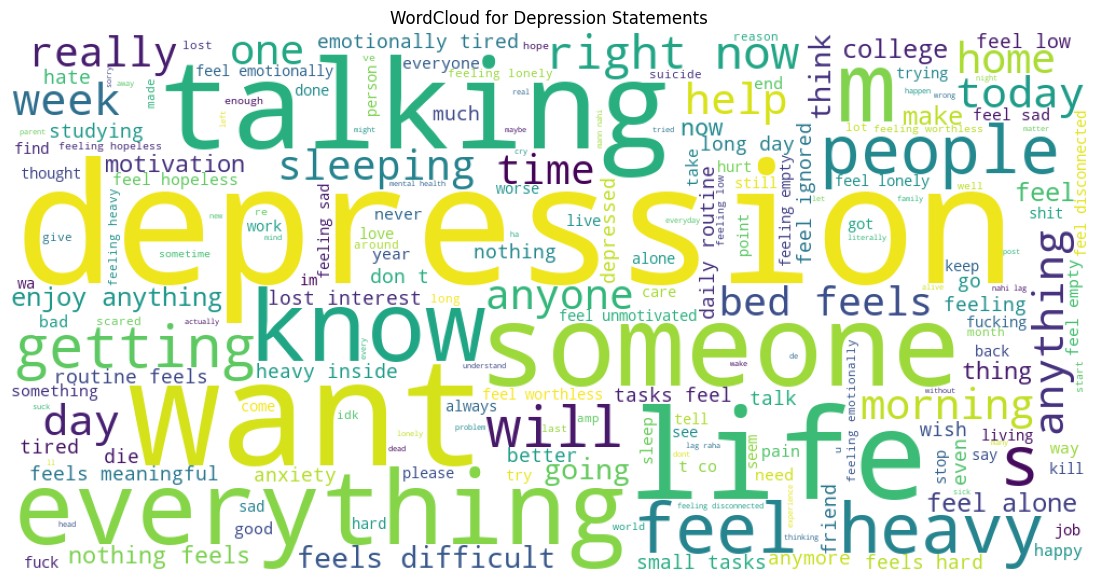

In [8]:
depression_text = " ".join(
    df[df["status"] == "Depression"]["statement"]
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(depression_text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("WordCloud for Depression Statements")

plt.show()

In [9]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["statement"])

y = df["status"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

In [11]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy: {:.2f}%".format(nb_accuracy*100))

Naive Bayes Accuracy: 88.65%


In [12]:
svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy: {:.2f}%".format(svm_accuracy*100))

SVM Accuracy: 94.10%


C:\Users\ranir\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


In [13]:
rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy: {:.2f}%".format(rf_accuracy*100))

Random Forest Accuracy: 92.25%


In [15]:
print("Classification Report (SVM Model):")

print(classification_report(y_test, svm_pred))

Classification Report (SVM Model):
              precision    recall  f1-score   support

     Anxiety       0.97      0.94      0.95      1025
  Depression       0.92      0.91      0.92       966
      Normal       0.90      0.97      0.93      1049
      Stress       0.99      0.95      0.97       960

    accuracy                           0.94      4000
   macro avg       0.94      0.94      0.94      4000
weighted avg       0.94      0.94      0.94      4000



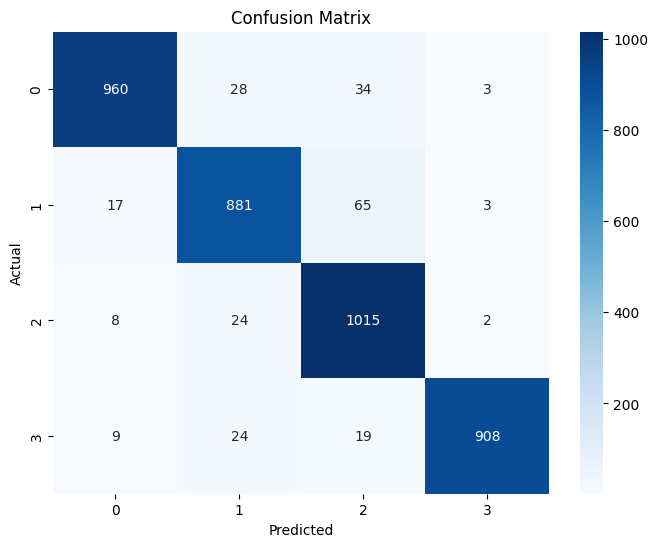

In [16]:
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

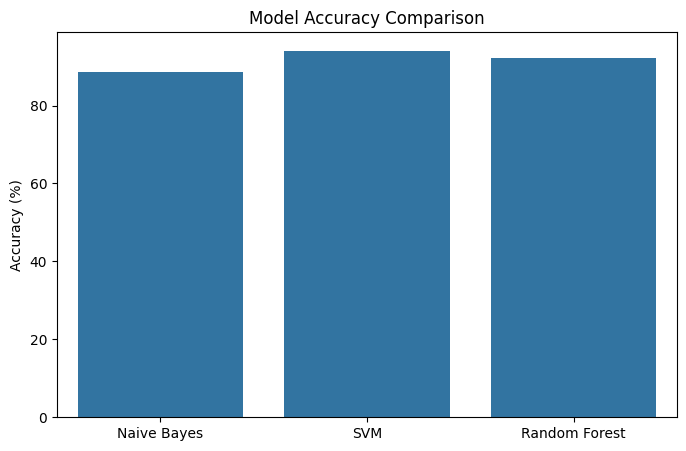

In [17]:
models = ["Naive Bayes", "SVM", "Random Forest"]

accuracies = [
    nb_accuracy*100,
    svm_accuracy*100,
    rf_accuracy*100
]

plt.figure(figsize=(8,5))

sns.barplot(x=models, y=accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")

plt.show()

In [18]:
sample_text = ["I feel very lonely and depressed"]

sample_vector = vectorizer.transform(sample_text)

prediction = svm_model.predict(sample_vector)

print("Predicted Mental Health Status:", prediction[0])

Predicted Mental Health Status: Depression
